In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDOneClassSVM
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    fbeta_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.kernel_approximation import RBFSampler
from pyathena.pandas.cursor import PandasCursor
from pyathena import connect

In [2]:
ACCESS_KEY = ""
SECRET_KEY = ""

In [3]:
cursor = connect(
    s3_staging_dir="s3://bdp-athena-results/",
    region_name="eu-north-1",
    aws_access_key_id=ACCESS_KEY,
    aws_secret_access_key=SECRET_KEY,
    cursor_class=PandasCursor,
).cursor()

features_table_name = "bdp.scaled_features"

In [4]:
validation_data = pd.read_parquet("benchmark")

In [5]:
X_val = validation_data.drop(columns=['label']).to_numpy(dtype=float)
y_val = validation_data['label'].values

In [6]:
y_val = np.where(y_val, -1, 1)

In [7]:
class VotingSGDOneClassSVM:
    def __init__(self, estimators):
        self.estimators = estimators

    def partial_fit(self, X):        
        for label, model in self.estimators:
            print(f"Training for {label}")            
            model.partial_fit(X)

    def predict(self, X):
        predictions = np.array([model.predict(X) for _, model in self.estimators])
        votes = np.sign(np.sum(predictions, axis=0))
        return votes

In [10]:
nu_values = [0.07, 0.03, 0.05, 0.1, 0.2, 0.22]
tol_values = [1e-7, 1e-9]
eta0_values = [1e-6, 1e-3]

estimators = [
    (f"nu: {nu}, tol: {tol}, eta0: {eta0}", 
     SGDOneClassSVM(nu=nu, shuffle=True, tol=tol, random_state=42, eta0=eta0, max_iter=10000, warm_start=True))
    for nu in nu_values
    for tol in tol_values
    for eta0 in eta0_values
]

rbf_sampler = RBFSampler(gamma=0.01, n_components=1000, random_state=42)
sgd_oc_svm_voting = VotingSGDOneClassSVM(estimators)

In [12]:
batch_size = 50000
offset = 0

while True:
    query = f"""
        SELECT * FROM 
        (SELECT row_number() over() AS rn, * FROM {features_table_name}) 
        WHERE rn BETWEEN {offset} AND {offset + batch_size - 1}
        """
    df = cursor.execute(query).as_pandas()
    df = df.drop(columns=['rn'])
    
    if df.empty:
        print("Training complete!")
        break
        
    X_batch_transformed = rbf_sampler.fit_transform(df) if offset == 0 else rbf_sampler.transform(df)

    sgd_oc_svm_voting.partial_fit(X_batch_transformed)    
        
    offset += batch_size
    print(f"Processed batch {int(offset / batch_size)}")

Training for nu: 0.07, tol: 1e-07, eta0: 1e-06
Training for nu: 0.07, tol: 1e-07, eta0: 0.001
Training for nu: 0.07, tol: 1e-09, eta0: 1e-06
Training for nu: 0.07, tol: 1e-09, eta0: 0.001
Training for nu: 0.03, tol: 1e-07, eta0: 1e-06
Training for nu: 0.03, tol: 1e-07, eta0: 0.001
Training for nu: 0.03, tol: 1e-09, eta0: 1e-06
Training for nu: 0.03, tol: 1e-09, eta0: 0.001
Training for nu: 0.05, tol: 1e-07, eta0: 1e-06
Training for nu: 0.05, tol: 1e-07, eta0: 0.001
Training for nu: 0.05, tol: 1e-09, eta0: 1e-06
Training for nu: 0.05, tol: 1e-09, eta0: 0.001
Training for nu: 0.1, tol: 1e-07, eta0: 1e-06
Training for nu: 0.1, tol: 1e-07, eta0: 0.001
Training for nu: 0.1, tol: 1e-09, eta0: 1e-06
Training for nu: 0.1, tol: 1e-09, eta0: 0.001
Training for nu: 0.2, tol: 1e-07, eta0: 1e-06
Training for nu: 0.2, tol: 1e-07, eta0: 0.001
Training for nu: 0.2, tol: 1e-09, eta0: 1e-06
Training for nu: 0.2, tol: 1e-09, eta0: 0.001
Training for nu: 0.22, tol: 1e-07, eta0: 1e-06
Training for nu: 0.22

In [13]:
X_val_transformed = rbf_sampler.transform(X_val)
y_pred = sgd_oc_svm_voting.predict(X_val_transformed)
y_pred = np.where(y_pred == 0, -1, 1)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RBFSampler was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

   Anomalous       0.21      0.16      0.18     14034
      Normal       0.78      0.83      0.80     50702

    accuracy                           0.68     64736
   macro avg       0.50      0.50      0.49     64736
weighted avg       0.66      0.68      0.67     64736

Accuracy: 0.68


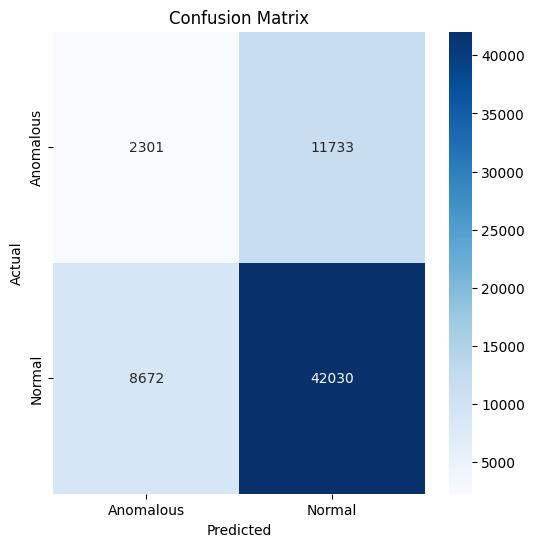

Precision: 0.78, Recall: 0.83, F1-Score: 0.80
AUC Score: 0.50
F2-Score: 0.82


In [14]:
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Anomalous", "Normal"]))

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_val, y_pred, labels=[-1, 1])

plt.figure(figsize=(6, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Anomalous", "Normal"],
    yticklabels=["Anomalous", "Normal"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

precision = precision_score(y_val, y_pred, pos_label=1)
recall = recall_score(y_val, y_pred, pos_label=1)
f1 = f1_score(y_val, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

auc = roc_auc_score(y_val, y_pred)
print(f"AUC Score: {auc:.2f}")

f2 = fbeta_score(y_val, y_pred, beta=2, pos_label=1)
print(f"F2-Score: {f2:.2f}")